In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 1. Exploratory Data Analysis

In [ ]:
df=pd.read_csv("case1Data.csv")
df.head()

Original Dataset:


,y,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,...,x_91,x_92,x_93,x_94,x_95,C_01,C_02,C_03,C_04,C_05
0,375.823073,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,...,-10.200888,3.980048,-4.433274,-1.473723,NaN,74.0,72.0,72.0,73.0,73.0
1,266.811730,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,...,-9.740207,NaN,-2.629314,4.816987,-12.240248,74.0,72.0,72.0,73.0,73.0
2,267.271759,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,...,-14.501970,10.054005,NaN,NaN,-11.107921,73.0,72.0,75.0,74.0,74.0
3,219.951294,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,...,-11.086963,2.019726,-8.531959,3.520833,NaN,71.0,72.0,73.0,71.0,72.0
4,289.697954,3.116458,-8.518713,-6.796050,NaN,7.646285,-3.118309,-13.102567,22.801217,16.680208,...,-9.117422,6.627601,-2.805531,5.914351,-11.240573,72.0,72.0,72.0,74.0,75.0


In [ ]:
y_class=df["y"]
print(f"Number of samples in y: {len(y_class)} ")

data=df.drop("y",axis=1)
print(f"Number of samples in x: {len(data)} ")
print(f"Number of features: {len(data.columns)}")

categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]
print(f"Number of categorical features: {len(categorical_data.columns)}")

numerical_data=data.drop(columns=categorical_data.columns)
print(f"Number of numerical features: {len(data.columns) - len(categorical_data.columns)}")

Number of samples in y: 100 
Number of samples in x: 100 
Number of features: 100
Number of categorical features: 5
Number of numerical features: 95


In [51]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_01    87 non-null     float64
 1   x_02    79 non-null     float64
 2   x_03    85 non-null     float64
 3   x_04    86 non-null     float64
 4   x_05    88 non-null     float64
 5   x_06    88 non-null     float64
 6   x_07    84 non-null     float64
 7   x_08    80 non-null     float64
 8   x_09    87 non-null     float64
 9   x_10    87 non-null     float64
 10  x_11    88 non-null     float64
 11  x_12    76 non-null     float64
 12  x_13    81 non-null     float64
 13  x_14    88 non-null     float64
 14  x_15    87 non-null     float64
 15  x_16    87 non-null     float64
 16  x_17    86 non-null     float64
 17  x_18    90 non-null     float64
 18  x_19    88 non-null     float64
 19  x_20    79 non-null     float64
 20  x_21    82 non-null     float64
 21  x_22    88 non-null     float64
 22  x_23    84 no

All features are float and have missing values

In [29]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "missing": data.isna().sum(),
    "missing_%": data.isna().mean()*100,
    "unique": data.nunique(),
    "mean": data.mean(numeric_only=True),
    "std": data.std(numeric_only=True),
    "variance": data.var(numeric_only=True),
    "min": data.min(numeric_only=True),
    "max": data.max(numeric_only=True)
})

summary.sort_values("missing_%", ascending=False)

,dtype,missing,missing_%,unique,mean,std,variance,min,max
x_85,float64,27,27.0,73,16.359404,3.151743,9.933483,9.305845,22.359613
x_12,float64,24,24.0,76,4.753164,2.823148,7.970165,-1.769365,11.707605
x_65,float64,22,22.0,78,-20.449232,2.896207,8.388013,-27.234760,-12.859887
C_02,float64,22,22.0,1,72.000000,0.000000,0.000000,72.000000,72.000000
C_01,float64,22,22.0,5,73.000000,1.376991,1.896104,71.000000,75.000000
C_05,float64,22,22.0,5,72.846154,1.358732,1.846154,71.000000,75.000000
C_03,float64,22,22.0,5,72.794872,1.361426,1.853480,71.000000,75.000000
C_04,float64,22,22.0,5,73.333333,1.401916,1.965368,71.000000,75.000000
x_20,float64,21,21.0,79,-9.971252,2.988498,8.931118,-17.103299,-3.547026
x_02,float64,21,21.0,79,-10.428729,2.553962,6.522724,-15.316637,-4.419087


- C_02 has always the same value, can be removed
- Features take positive and negative values, with some always negative or positive, and other alternating

In [68]:
skews=data.skew().sort_values()
skews_filtered = skews[(skews > 0.5) | (skews < -0.5)]
print(skews_filtered)

x_42   -0.817905
x_89   -0.622233
x_26   -0.621106
x_49    0.504576
x_70    0.621823
dtype: float64


Most features are approximately symmetric

### 1.1 Feature Variance

In [18]:
numeric_cols = numerical_data.columns
feature_variance = numerical_data[numeric_cols].var()
feature_variance.min(), feature_variance.max()

(np.float64(5.976478283172355), np.float64(10.860976917924484))

From this range we conclude:
- Features have similar scales
- No almost constant variables
- No feature is dramatically more variable than other

### 1.2 Missing values

Maximum missing values in a column: 27
Features with maximum missing values: ['x_85']


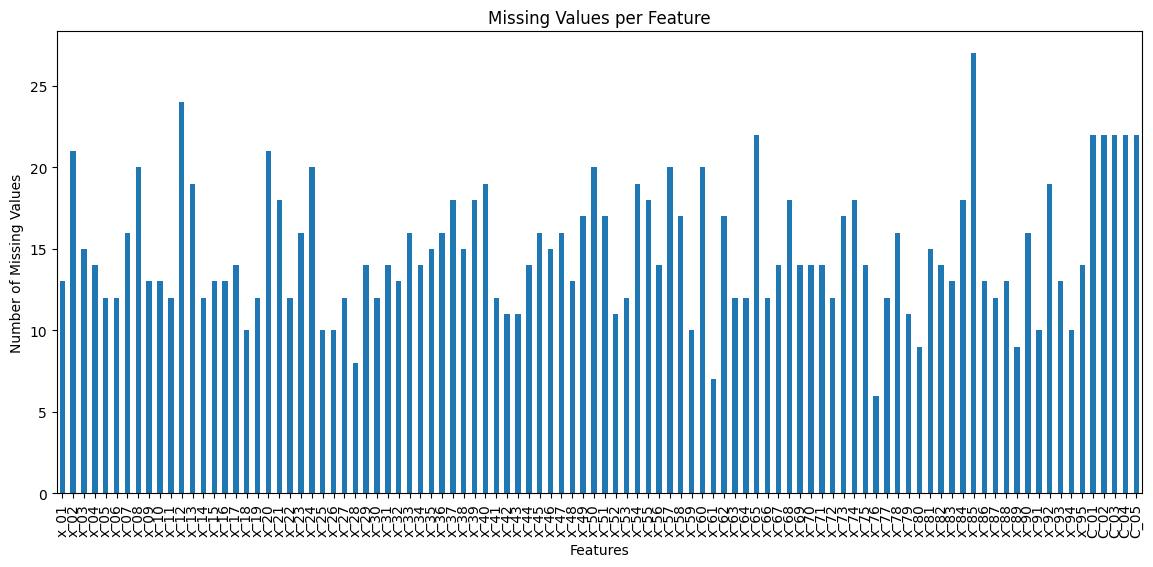

In [19]:
missing_per_column = data.isnull().sum()

max_missing_col = missing_per_column.max()
print("Maximum missing values in a column:", max_missing_col)

features_with_max_missing = missing_per_column[missing_per_column == max_missing_col].index.tolist()
print("Features with maximum missing values:", features_with_max_missing)

plt.figure(figsize=(14,6))
missing_per_column.plot(kind='bar')
plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.show()

All categorical features have the same number of missing values.

Maximum missing values in a row: 32
Row index(es) with maximum missing values: [57]


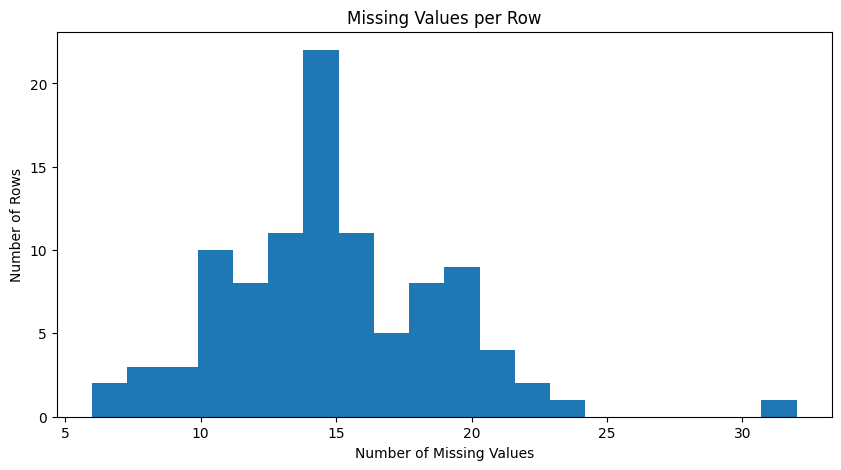

In [21]:
missing_per_row = data.isnull().sum(axis=1)

max_missing_row = missing_per_row.max()
print("Maximum missing values in a row:", max_missing_row)

rows_with_max_missing = missing_per_row[missing_per_row == max_missing_row].index.tolist()
print("Row index(es) with maximum missing values:", rows_with_max_missing)

plt.figure(figsize=(10,5))
plt.hist(missing_per_row, bins=20)
plt.title("Missing Values per Row")
plt.xlabel("Number of Missing Values")
plt.ylabel("Number of Rows")
plt.show()

- Impute the median of the feature for missing values since we have few obs

### 1.1 Categorical Variables

Already know C2 has always the same value

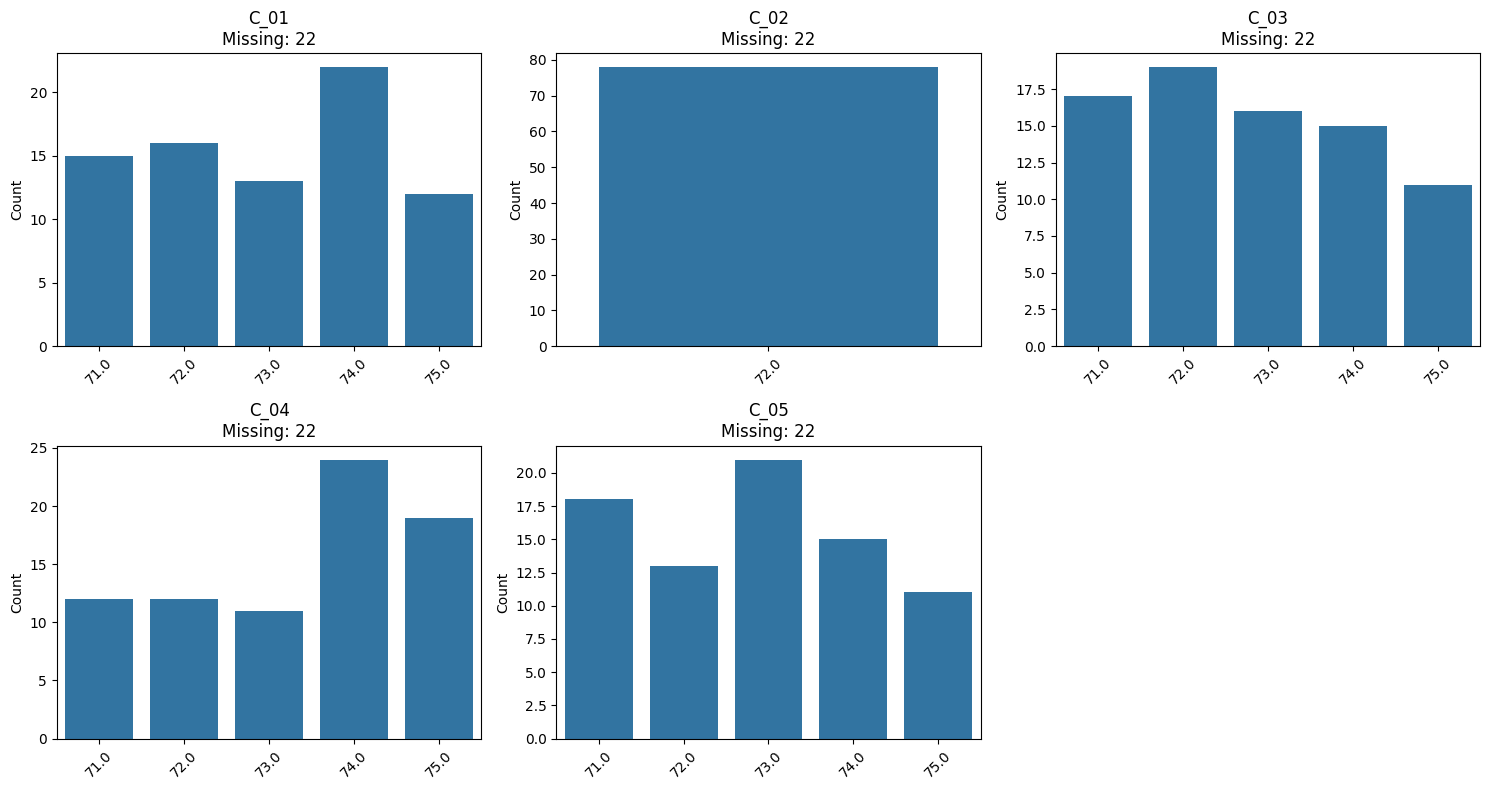

In [35]:
cols = categorical_data.columns
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.countplot(data=categorical_data,x=col,order=sorted(categorical_data[col].dropna().unique()),ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
    n_missing = categorical_data[col].isna().sum()
    ax.set_title(f"{col}\nMissing: {n_missing}")

for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
all_missing_rows = categorical_data.isna().all(axis=1)
print("Number of rows with all categorical values missing:", all_missing_rows.sum())
print("Row indices with all categorical values missing:", all_missing_rows[all_missing_rows].index.tolist())

Number of rows with all categorical values missing: 22
Row indices with all categorical values missing: [8, 10, 14, 16, 21, 24, 28, 30, 34, 40, 57, 58, 59, 62, 64, 66, 72, 84, 85, 88, 91, 99]


- C_01, C_03, C_04, C_05 all have values from 71 to 75 (5 possible values)
- WARNING: C2 might be important in the test data
- there are 22 rows with no categorical data and the rest of the rows all have categorical data

### 1.4 Target Variable

In [ ]:
print(f"Class value type: {y_class.dtypes}") 
print(f"Missing values: {y_class.isna().sum()}")
print(f"Missing values (%): {y_class.isna().mean()*100}")
print(f"Unique values: {y_class.nunique()}")
print(f"Mean: {y_class.mean()}")
print(f"Median: {y_class.median()}")
print(f"Standard deviation: {y_class.std()}")
print(f"Variance: {y_class.var()}")
print(f"Min: {y_class.min()}")
print(f"Max: {y_class.max()}")
print(f"Skewness: {y_class.skew()}")

Class value type: float64
Missing values: 0
Missing values (%): 0.0
Unique values: 100
Mean: 211.5212379629106
Median: 215.25794722553087
Standard deviation: 72.47649920974135
Variance: 5252.842937699638
Min: 39.70221769951189
Max: 375.823073005362
Skewness: -0.12587740767843938


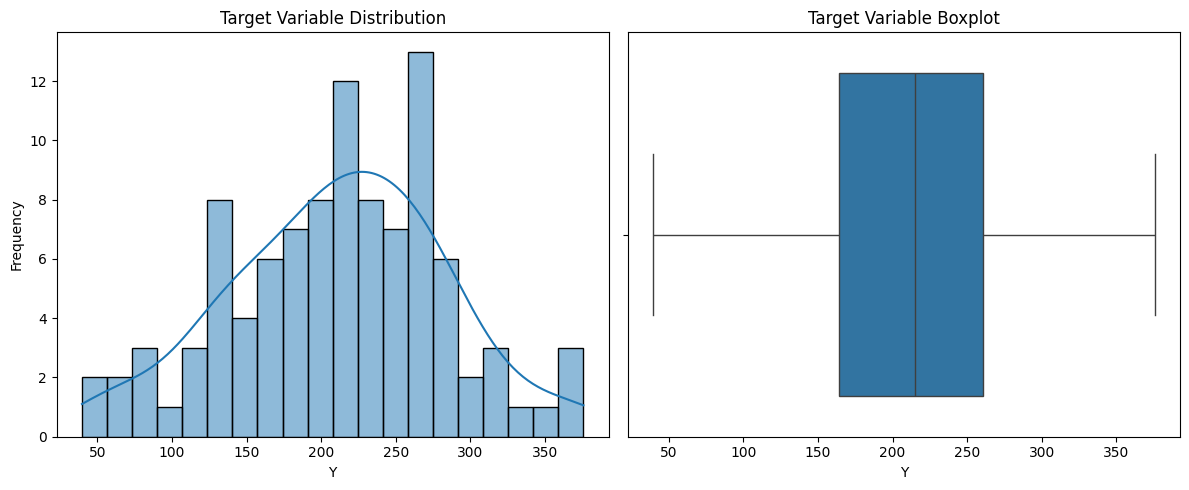

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
sns.histplot(y_class, kde=True, bins=20, ax=axes[0])
axes[0].set_title("Target Variable Distribution")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=y_class, ax=axes[1])
axes[1].set_title("Target Variable Boxplot")
axes[1].set_xlabel("Y")

plt.tight_layout()
plt.show()

- not very skewed
- very different scale from X

### 1.3 Correlation

Linear correlation

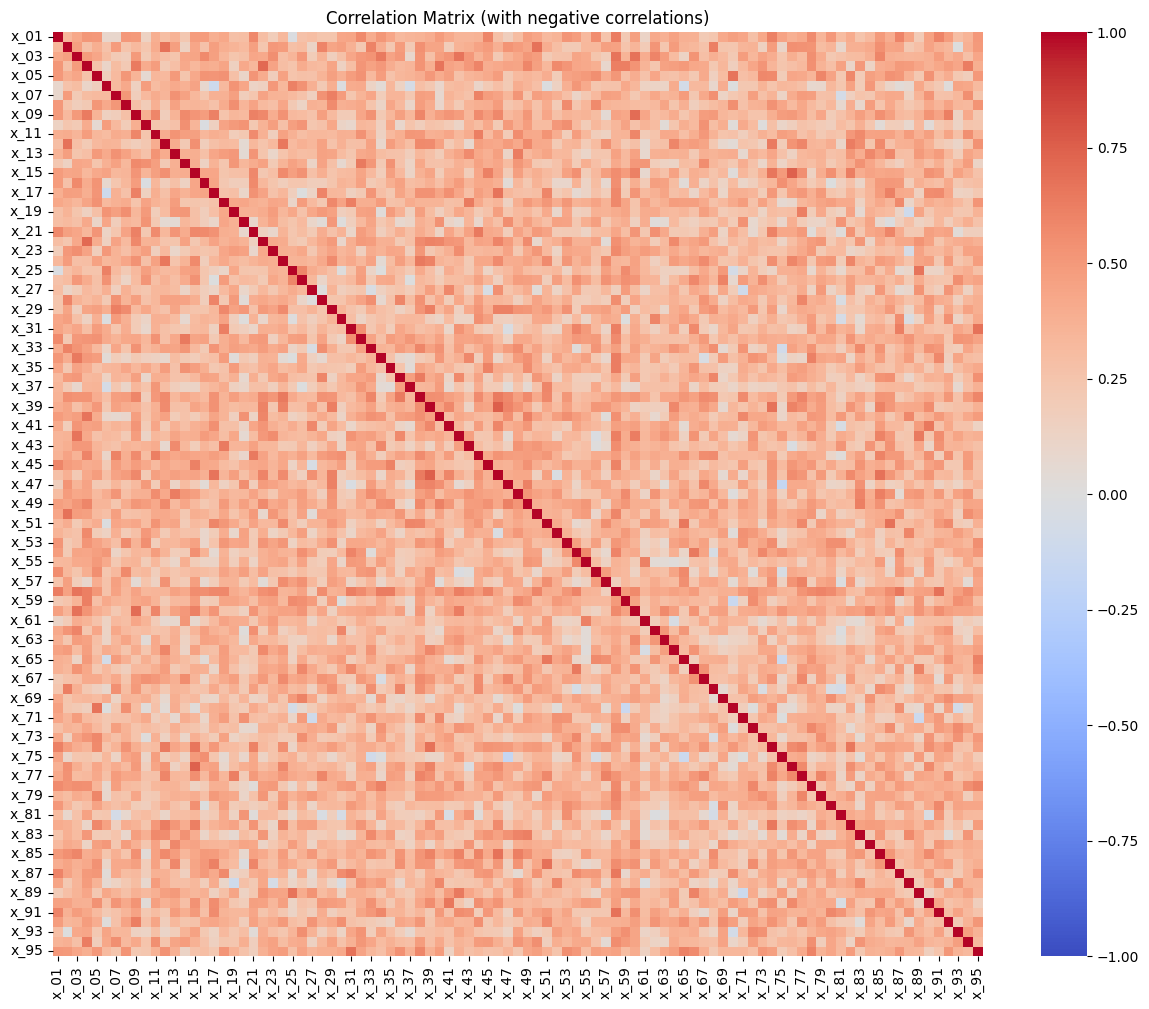

In [58]:
corr = numerical_data.corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=False)
plt.title("Correlation Matrix (with negative correlations)")
plt.show()

Spearman correlation

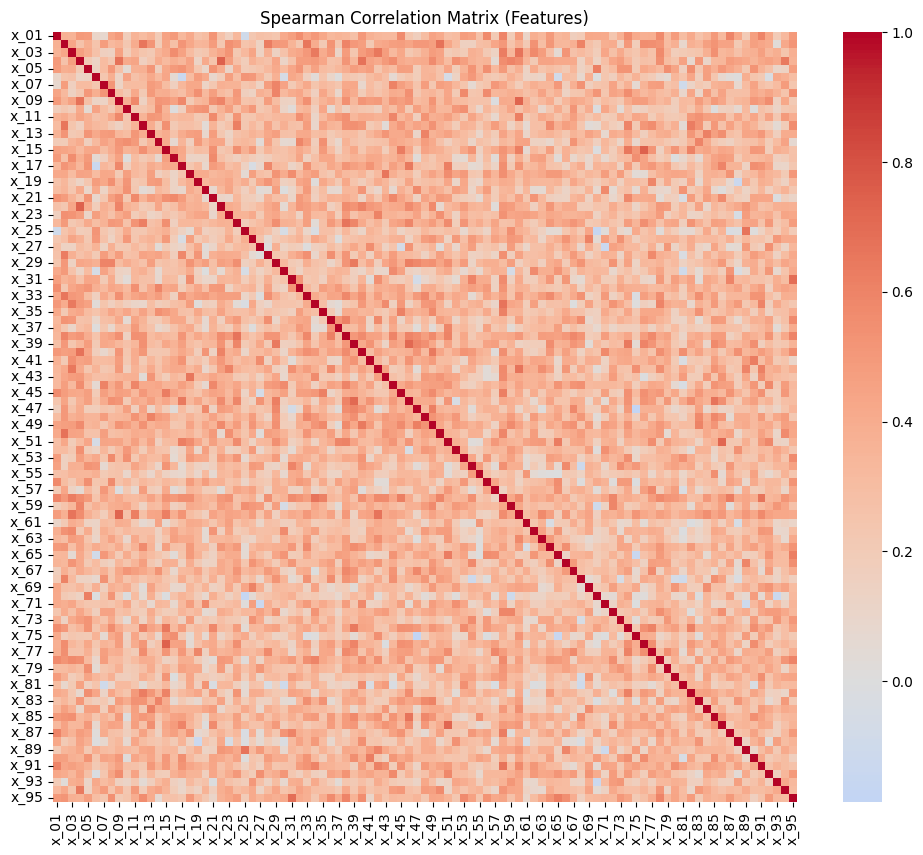

In [59]:
spearman_corr = numerical_data.corr(method='spearman')
plt.figure(figsize=(12,10))
sns.heatmap(spearman_corr, cmap='coolwarm', center=0)
plt.title("Spearman Correlation Matrix (Features)")
plt.show()

Linear correlation above 0.7

In [60]:
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
high_corr = corr_pairs[corr_pairs > 0.7].sort_values(ascending=False)
print(high_corr)

x_46  x_39    0.751971
x_39  x_46    0.751971
x_76  x_15    0.747985
x_15  x_76    0.747985
x_04  x_22    0.716159
x_22  x_04    0.716159
dtype: float64


In [61]:
spear_pairs = spearman_corr.unstack()
spear_pairs = spear_pairs[spear_pairs.index.get_level_values(0) != spear_pairs.index.get_level_values(1)]
high_corr = spear_pairs[spear_pairs > 0.7].sort_values(ascending=False)
print(high_corr)

x_04  x_22    0.746083
x_22  x_04    0.746083
x_76  x_15    0.744234
x_15  x_76    0.744234
x_09  x_60    0.731047
x_60  x_09    0.731047
x_51  x_86    0.717438
x_86  x_51    0.717438
x_46  x_39    0.712886
x_39  x_46    0.712886
dtype: float64


Top 10 features by absolute Pearson correlation with Y:
 x_32    0.770303
x_36    0.478040
x_31    0.426011
x_14    0.404301
x_94    0.330637
x_40    0.325519
x_55    0.323713
x_28    0.313412
x_93    0.303670
x_11    0.302154
dtype: float64

Top 10 features by absolute Spearman correlation with Y:
 x_32    0.778323
x_36    0.442867
x_31    0.418425
x_14    0.401113
x_73    0.345661
x_11    0.339069
x_94    0.327423
x_40    0.312827
x_04    0.305684
x_22    0.303547
dtype: float64


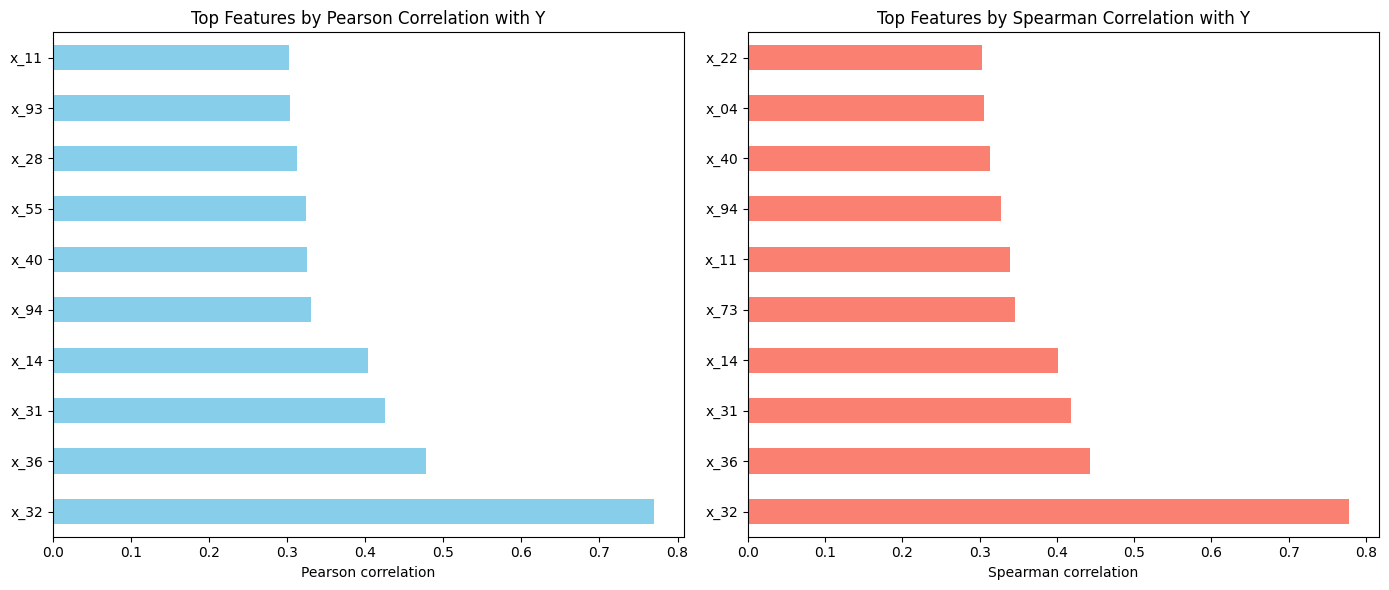

In [ ]:
pearson_corr_target = numerical_data.corrwith(y_class, method='pearson').sort_values(ascending=False)
spearman_corr_target = numerical_data.corrwith(y_class, method='spearman').sort_values(ascending=False)

top_pearson = pearson_corr_target.abs().sort_values(ascending=False).head(10)
top_spearman = spearman_corr_target.abs().sort_values(ascending=False).head(10)

print("Top 10 features by absolute Pearson correlation with Y:\n", top_pearson)
print("\nTop 10 features by absolute Spearman correlation with Y:\n", top_spearman)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
top_pearson.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title("Top Features by Pearson Correlation with Y")
axes[0].set_xlabel("Pearson correlation")

top_spearman.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title("Top Features by Spearman Correlation with Y")
axes[1].set_xlabel("Spearman correlation")

plt.tight_layout()
plt.show()

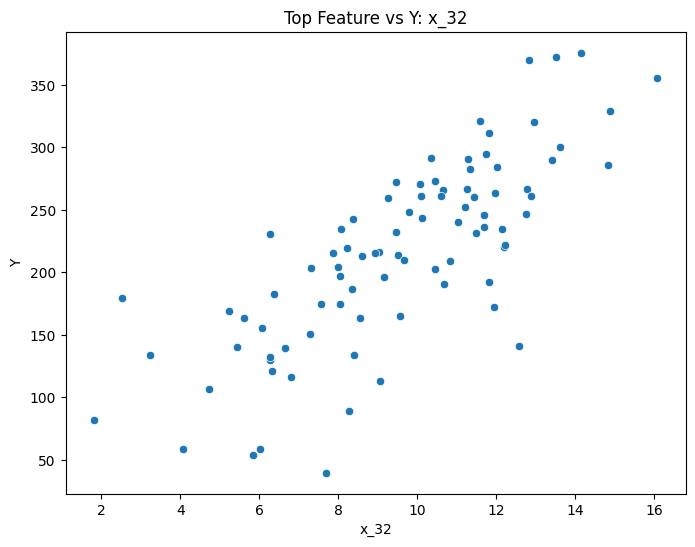

In [71]:
top_feature = top_spearman.index[0]  
plt.figure(figsize=(8, 6))
sns.scatterplot(x=numerical_data[top_feature], y=y_class)
plt.title(f"Top Feature vs Y: {top_feature}")
plt.xlabel(top_feature)
plt.ylabel("Y")
plt.show()

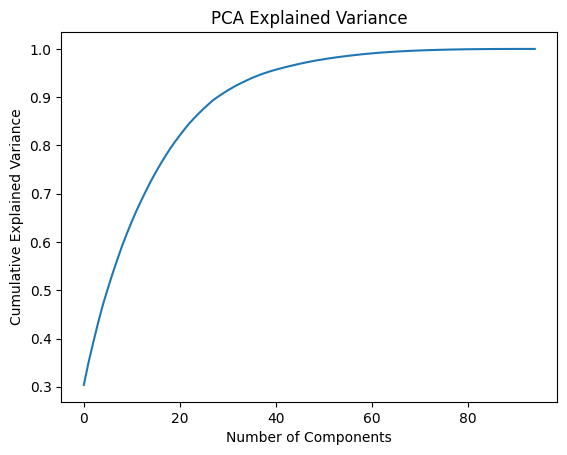

In [ ]:
numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_data)

pca = PCA()
pca.fit(X_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

**Overview**
- Multicollinearity is moderate but not severe
- Impute missing values with median.
- on ehot encode categorical
- Add missing as its own category.

## 2. Data Preprocessing

Download dataset again, to make sure there are no mistakes

In [4]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

Replace NaN values in numerical features by their median

In [5]:
numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
print(numerical_data.isna().sum())

x_01    0
x_02    0
x_03    0
x_04    0
x_05    0
       ..
x_91    0
x_92    0
x_93    0
x_94    0
x_95    0
Length: 95, dtype: int64


Remove categorical feature C_02 since it presents the same value for all rows (72 and NaN)

In [6]:
categorical_data.drop(columns="C_02", inplace=True)

Replace NaN values in categorical features by a new categorical value "missing"

In [7]:
categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64


One-hot encode categorical data

In [8]:
categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

,C_01_71.0,C_01_72.0,C_01_73.0,C_01_74.0,C_01_75.0,C_01_missing,C_03_71.0,C_03_72.0,C_03_73.0,C_03_74.0,...,C_04_73.0,C_04_74.0,C_04_75.0,C_04_missing,C_05_71.0,C_05_72.0,C_05_73.0,C_05_74.0,C_05_75.0,C_05_missing
0,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


Rename columns to remove .0 from their names

In [9]:
categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

,C_01_71,C_01_72,C_01_73,C_01_74,C_01_75,C_01_missing,C_03_71,C_03_72,C_03_73,C_03_74,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


Join numerical and categorical features

In [10]:
X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-3.771067,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,-5.793856,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.435510,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,-5.793856,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


## 3. Lasso with LARS

*Strengths:*

- Computes the entire LASSO path efficiently — fast when p ≈ n or p < n.

- Provides the exact solution along the path, so the CV-selected alpha is reliable.

- Works well for small datasets with many correlated features (like your 100×100 case).

*Limitations:*

- Can be sensitive to numerical instability if predictors are highly correlated or scale varies

In [12]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoLarsCV
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoLars
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


In [14]:
def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

The baseline RMSE (predicting the mean) is a reference point for performance, shows if the your model learns signal more than just guessing the average

In [63]:
X_np = X.values
y_np = y_class.values
baseline_rmse = np.sqrt(np.mean((y_np - np.mean(y_np))**2))
baseline_rmse

np.float64(72.11320619916052)

### 3.1 Nested Cross Validation

We did multiple repetitions of nested cv to obtain an unbiased estimate of the model’s predictive performance (RSME). The dataset was split into 5 outer folds, repeated 10 times with different seeds to reduce variability because of the small number of samples. Ineach outer training fold, we used 10-fold inner cv to select the optimal LASSO parameter, alpha/lambda. Predictions on the outer test folds were used to compute the mean squared error and derive the RMSE. This approach avoids overfitting by ensuring that the test data in each outer fold is completely unseen during model training and hyperparameter selection. Tracking best_alpha across folds also provides insight into the stability of feature selection. Repeated nested CV is important in high-dimensional settings, as it balances the bias-variance tradeoff and gives a more reliable estimate of out-of-sample performance than a single train-test split

In [ ]:
X_np = X.values
y_np = y_class.values

num_cols = numerical_data.columns
cat_cols = categorical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]

outer_folds = 5
n_repeats = 10
#outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42)

# for the repetitions of the outer cv
repetitions_rmse = []
best_alphas = []
# residual analysis
y_cv_true = []
y_cv_pred = []


for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)  # change seed each repeat
    
    # an error value per outer test fold (5 test folds)
    rmse_per_fold = []

    # outer cv for model evaluation
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_out_train = X_np[train_out_idx].copy()
        y_out_train = y_np[train_out_idx]
        X_out_test = X_np[test_out_idx].copy()
        y_out_test = y_np[test_out_idx]
        
        #for X: standardize only numerical features
        scaler = StandardScaler()
        X_out_train[:, num_idx] = scaler.fit_transform(X_out_train[:, num_idx])
        X_out_test[:, num_idx] = scaler.transform(X_out_test[:, num_idx])
        #for y: only center
        y_out_train_centered, mu = centerData(y_out_train)
        y_out_test_centered = y_out_test - mu

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            # automatic inner cv for model selection
            lasso_lars_model = LassoLarsCV(cv=5, fit_intercept=False)
            lasso_lars_model.fit(X_out_train, y_out_train_centered)

        best_alpha = lasso_lars_model.alpha_
        best_alphas.append(best_alpha)
        coef_best = lasso_lars_model.coef_

        # Number of selected features
        n_selected = np.sum(coef_best != 0)
        print(f"Repeat {repeat}, fold selected {n_selected} features")

        # evaluation on outer test set
        y_out_pred = X_out_test @ coef_best
        fold_rmse= np.sqrt(np.mean((y_out_pred - y_out_test_centered)**2))
        rmse_per_fold.append(fold_rmse)
        y_cv_true.extend(y_out_test_centered) 
        y_cv_pred.extend(y_out_pred)

    repetitions_rmse.extend(rmse_per_fold)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")

print(f"Mean best_alpha: {np.mean(best_alphas):.4f}")
print(f"Std of best_alpha: {np.std(best_alphas):.4f}")

Repeat 0, fold selected 37 features
Repeat 0, fold selected 59 features
Repeat 0, fold selected 44 features
Repeat 0, fold selected 39 features
Repeat 0, fold selected 25 features
Repeat 1, fold selected 19 features
Repeat 1, fold selected 44 features
Repeat 1, fold selected 51 features
Repeat 1, fold selected 57 features
Repeat 1, fold selected 11 features
Repeat 2, fold selected 36 features
Repeat 2, fold selected 67 features
Repeat 2, fold selected 14 features
Repeat 2, fold selected 41 features
Repeat 2, fold selected 23 features
Repeat 3, fold selected 45 features
Repeat 3, fold selected 29 features
Repeat 3, fold selected 14 features
Repeat 3, fold selected 55 features
Repeat 3, fold selected 27 features
Repeat 4, fold selected 41 features
Repeat 4, fold selected 16 features
Repeat 4, fold selected 52 features
Repeat 4, fold selected 44 features
Repeat 4, fold selected 38 features
Repeat 5, fold selected 38 features
Repeat 5, fold selected 29 features
Repeat 5, fold selected 18 f

- Some folds pick too many variables, overfit, RMSE spikes on outer test set
- Some folds pick very few variables, underfit, RMSE is moderate
- This explains ±41 RMSE, even though mean RMSE ~ 34


Text(0.5, 1.0, 'Distribution of Fold RMSE')

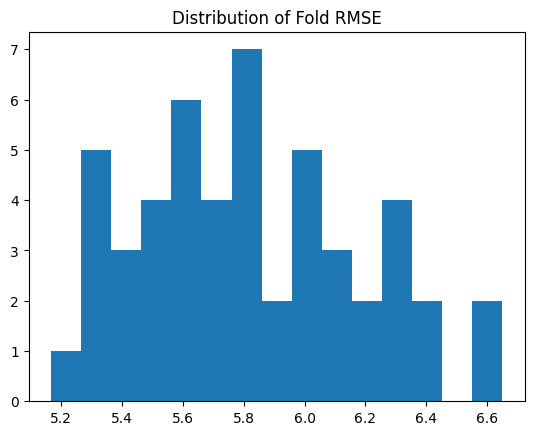

In [65]:
plt.hist(np.sqrt(repetitions_rmse), bins=15)
plt.title("Distribution of Fold RMSE")

### 3.2 Residuals

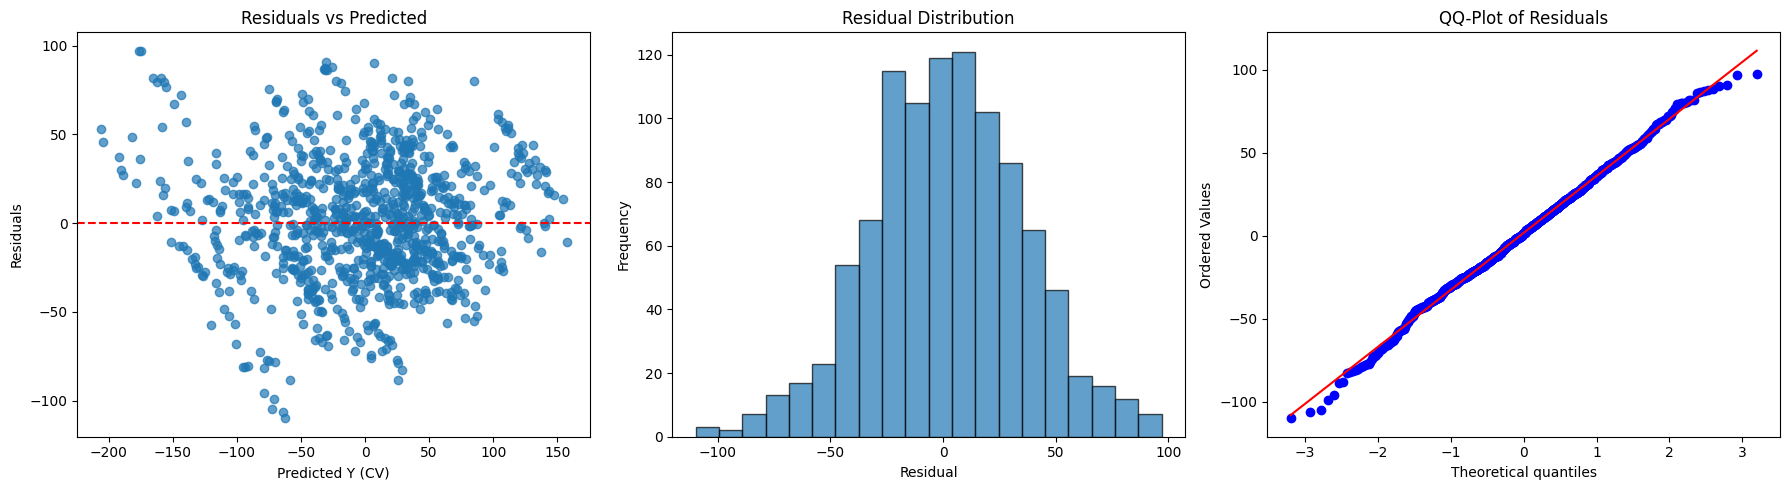

In [66]:
y_cv_true = np.array(y_cv_true)
y_cv_pred = np.array(y_cv_pred)

residuals = y_cv_true - y_cv_pred

fig, axes = plt.subplots(1, 3, figsize=(18,5))  

axes[0].scatter(y_cv_pred, residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Y (CV)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot of Residuals")
plt.tight_layout()  
plt.show()

Residuals from cross-validated predictions approximately follow a normal distribution, centered at zero, indicating that the LASSO-LARS model captures the main linear signal without systematic bias. The absence of strong skew or heavy tails suggests that variance is reasonably constant across predictions.

Residual analysis indicates that residuals are roughly centered around zero, with an approximately normal distribution. Minor heteroskedasticity is observed for extreme predicted values, and slight deviations appear in the QQ-plot tails, consistent with small sample size and fold-to-fold variability. Overall, the LASSO model assumptions appear reasonable for this dataset.

### 3.3 Cross validation with all data to choose the final lambda

We use LassoLarsCV with 10-fold cv to automatically select the optimal regularization parameter (alpha/lambda) that minimizes the mean squared error. By fitting the model on the full dataset with this selected alpha, we obtain the final set of coefficients, which are sparse due to the LASSO penalty. Counting the non-zero coefficients provides insight into which features contribute meaningfully to the model, allowing for a balance between predictive accuracy and model simplicity.

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)
y_centered, mu = centerData(y_class.values)

# select best alpha
lasso_lars_final = LassoLarsCV(cv=10, fit_intercept=False)
lasso_lars_final.fit(X_scaled, y_centered)
best_alpha = lasso_lars_final.alpha_
print(f"Selected alpha: {best_alpha}")

# see how many coefs are not zero
coef_final = lasso_lars_final.coef_ 
non_zero_count = np.sum(coef_final != 0)
print(f"Number of non-zero coefficients: {non_zero_count}")

Selected alpha: 2.9509130449142194
Number of non-zero coefficients: 24


### 3.4 1-SE rule lambda

Alpha chosen by 1 SE rule: 6.507416253815136
Number of non-zero coefficients (1 SE): 9
Features selected by 1-SE Lasso:
x_10
x_29
x_30
x_32
x_36
x_41
x_45
x_62
x_74


Alpha chosen by min CV MSE: 2.9509130449142194
Number of non-zero coefficients (min CV MSE): 24


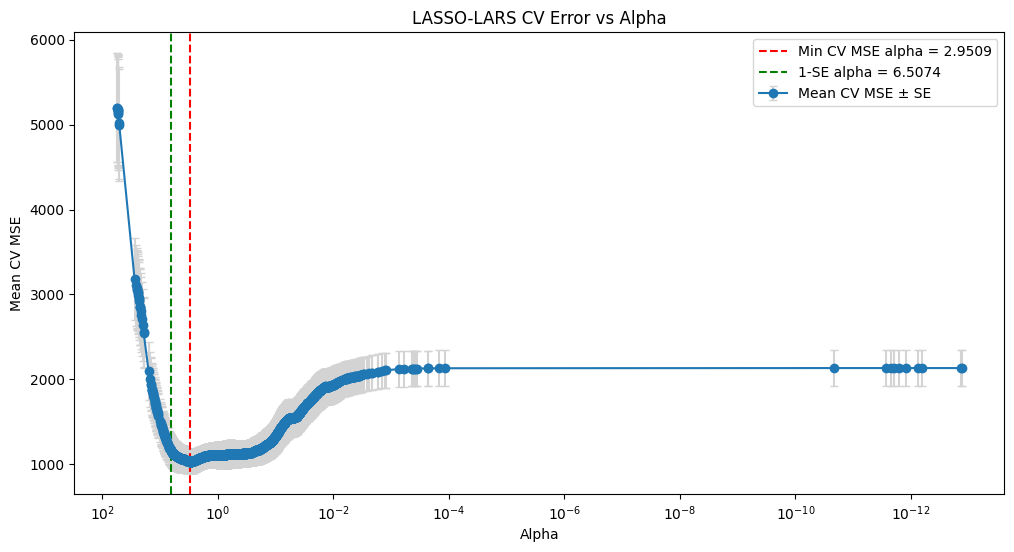

In [68]:
mse_path = lasso_lars_final.mse_path_ 
mse_mean = np.mean(mse_path, axis=1)
mse_std = np.std(mse_path, axis=1) / np.sqrt(mse_path.shape[1])

min_idx = np.argmin(mse_mean)
min_mse = mse_mean[min_idx]
min_se = mse_std[min_idx]

threshold = min_mse + min_se

# find largest alpha with MSE <= threshold
alphas = lasso_lars_final.cv_alphas_
one_se_idx = np.where(mse_mean <= threshold)[0]  
idx_1se = np.max(one_se_idx)
alpha_1se = alphas[idx_1se]

# coefs of 1se alpha
# refit on the full scaled data, coefs are not stored by lassolars cv
lasso_lars_1se = LassoLars(alpha=alpha_1se, fit_intercept=False)
lasso_lars_1se.fit(X_scaled, y_centered)
coef_1se = lasso_lars_1se.coef_
non_zero_1se = np.sum(coef_1se != 0)

print(f"Alpha chosen by 1 SE rule: {alpha_1se}")
print(f"Number of non-zero coefficients (1 SE): {non_zero_1se}")
# Get names of features with non-zero coefficients
selected_features = X.columns[coef_1se != 0]

# Print them
print("Features selected by 1-SE Lasso:")
for f in selected_features:
    print(f)
print("\n")
print(f"Alpha chosen by min CV MSE: {best_alpha}")
print(f"Number of non-zero coefficients (min CV MSE): {non_zero_count}")


plt.figure(figsize=(12,6))
plt.errorbar(alphas, mse_mean, yerr=mse_std, fmt='-o', ecolor='lightgray', capsize=3,label='Mean CV MSE ± SE')
plt.axvline(best_alpha, color='red', linestyle='--',label=f'Min CV MSE alpha = {best_alpha:.4f}')
plt.axvline(alpha_1se, color='green', linestyle='--',label=f'1-SE alpha = {alpha_1se:.4f}')
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LASSO-LARS CV Error vs Alpha")
plt.xscale('log')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

## 4. Lasso with coordinate descent

*Strengths:*

- Works for larger datasets, p >> n, or sparse matrices.

- Handles arbitrary scaling and more flexible settings (e.g., non-zero intercept).

- Often slightly more stable numerically than LARS when features are correlated.

*Limitations:*

- Slightly slower for small p.

- Produces approximate solutions for the LASSO path, but usually negligible difference.

### 4.1 Nested Cross Validation

In [15]:
X_np = X.values
y_np = y_class.values

num_cols = numerical_data.columns
cat_cols = categorical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]

outer_folds = 5
n_repeats = 10
outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42)

# for the repetitions of the outer cv
repetitions_rmse = []
best_alphas = []
# residual analysis
y_cv_true = []
y_cv_pred = []


for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)  # change seed each repeat
    
    # an error value per outer test fold (5 test folds)
    rmse_per_fold = []

    # outer cv for model evaluation
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_out_train = X_np[train_out_idx].copy()
        y_out_train = y_np[train_out_idx]
        X_out_test = X_np[test_out_idx].copy()
        y_out_test = y_np[test_out_idx]
        
        #for X: standardize only numerical features
        scaler = StandardScaler()
        X_out_train[:, num_idx] = scaler.fit_transform(X_out_train[:, num_idx])
        X_out_test[:, num_idx] = scaler.transform(X_out_test[:, num_idx])
        #for y: only center
        y_out_train_centered, mu = centerData(y_out_train)
        y_out_test_centered = y_out_test - mu

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            # automatic inner cv for model selection
            lasso_model = LassoCV(cv=10, fit_intercept=False, max_iter=10000, n_jobs=-1)
            lasso_model.fit(X_out_train, y_out_train_centered)

        best_alpha = lasso_model.alpha_
        best_alphas.append(best_alpha)
        coef_best = lasso_model.coef_

        # Number of selected features
        n_selected = np.sum(coef_best != 0)
        print(f"Repeat {repeat}, fold selected {n_selected} features")

        # evaluation on outer test set
        y_out_pred = X_out_test @ coef_best
        fold_rmse = np.sqrt(np.mean((y_out_pred - y_out_test_centered)**2))
        rmse_per_fold.append(fold_rmse)
        y_cv_true.extend(y_out_test_centered) 
        y_cv_pred.extend(y_out_pred)

    repetitions_rmse.extend(rmse_per_fold)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")

print(f"Mean best_alpha: {np.mean(best_alphas):.4f}")
print(f"Std of best_alpha: {np.std(best_alphas):.4f}")

overall_std = np.std(repetitions_rmse)
print(f"Overall std: {overall_std:.4f}")

Repeat 0, fold selected 37 features
Repeat 0, fold selected 59 features
Repeat 0, fold selected 44 features
Repeat 0, fold selected 39 features
Repeat 0, fold selected 25 features
Repeat 1, fold selected 19 features
Repeat 1, fold selected 44 features
Repeat 1, fold selected 50 features
Repeat 1, fold selected 56 features
Repeat 1, fold selected 11 features
Repeat 2, fold selected 36 features
Repeat 2, fold selected 70 features
Repeat 2, fold selected 14 features
Repeat 2, fold selected 43 features
Repeat 2, fold selected 22 features
Repeat 3, fold selected 45 features
Repeat 3, fold selected 30 features
Repeat 3, fold selected 15 features
Repeat 3, fold selected 55 features
Repeat 3, fold selected 27 features
Repeat 4, fold selected 40 features
Repeat 4, fold selected 16 features
Repeat 4, fold selected 51 features
Repeat 4, fold selected 59 features
Repeat 4, fold selected 41 features
Repeat 5, fold selected 38 features
Repeat 5, fold selected 29 features
Repeat 5, fold selected 18 f

### 4.2 Residuals

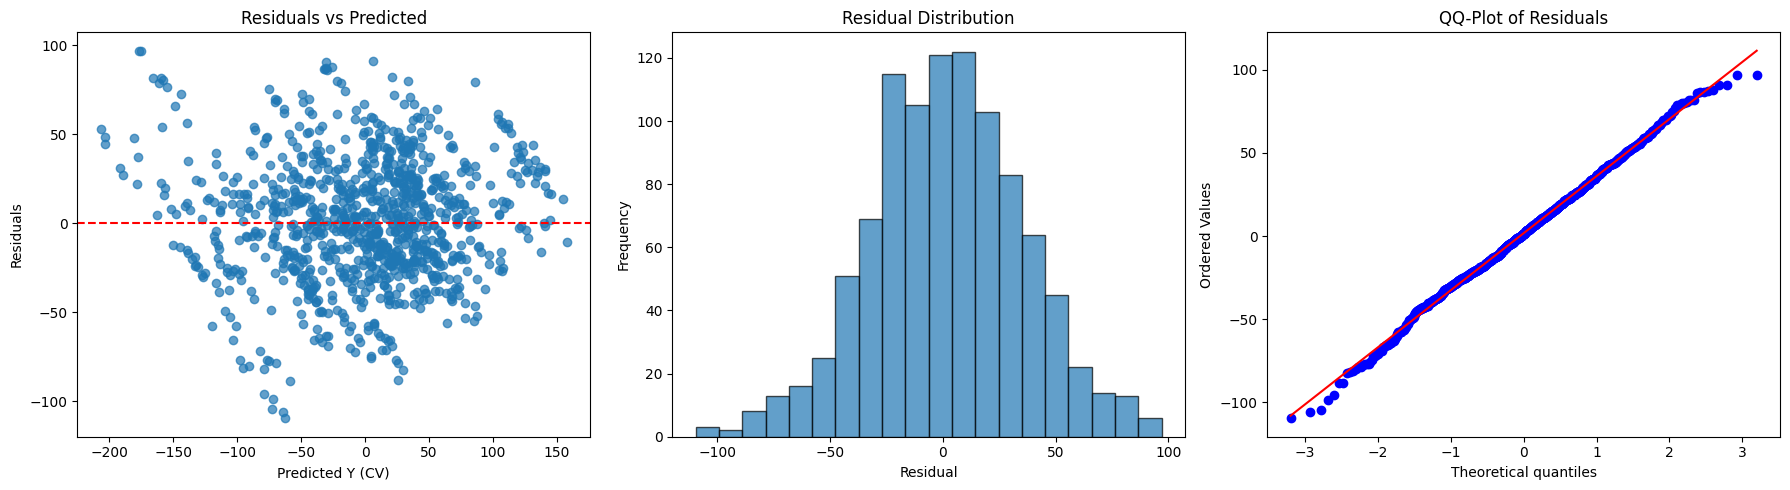

In [16]:
y_cv_true = np.array(y_cv_true)
y_cv_pred = np.array(y_cv_pred)

residuals = y_cv_true - y_cv_pred

fig, axes = plt.subplots(1, 3, figsize=(18,5))  

axes[0].scatter(y_cv_pred, residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Y (CV)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot of Residuals")
plt.tight_layout()  
plt.show()

### 4.3 Cross validation with all data to choose the final lambda

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)
y_centered, mu = centerData(y_class.values)

# select best alpha
lasso_final = LassoCV(cv=10, fit_intercept=False)
lasso_final.fit(X_scaled, y_centered)
best_alpha = lasso_final.alpha_
print(f"Selected alpha: {best_alpha}")

# see how many coefs are not zero
coef_final = lasso_final.coef_ 
non_zero_count = np.sum(coef_final != 0)
print(f"Number of non-zero coefficients: {non_zero_count}")

c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.091e+01, tolerance: 4.601e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.888e+01, tolerance: 4.557e+01
  model = cd_fast.enet_coordinate_descent(


Selected alpha: 3.030592831788761
Number of non-zero coefficients: 23


### 4.4 1SE rule

Alpha chosen by 1 SE rule: 6.529214328167667
Number of non-zero coefficients (1 SE): 9


Alpha chosen by min CV MSE: 3.030592831788761
Number of non-zero coefficients (min CV MSE): 23


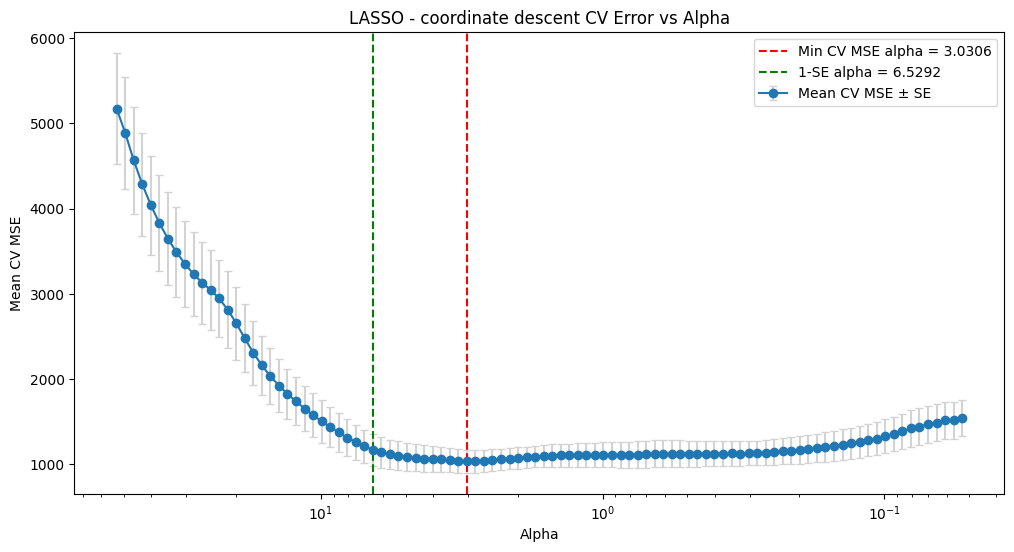

In [18]:
mse_path = lasso_final.mse_path_ 
mse_mean = np.mean(mse_path, axis=1)
mse_std = np.std(mse_path, axis=1) / np.sqrt(mse_path.shape[1])

min_idx = np.argmin(mse_mean)
min_mse = mse_mean[min_idx]
min_se = mse_std[min_idx]

threshold = min_mse + min_se

# find largest alpha with MSE <= threshold
alphas = lasso_final.alphas_
one_se_idx = np.where(mse_mean <= threshold)[0] 
alpha_1se = np.max(alphas[one_se_idx]) 

# coefs of 1se alpha
# refit on the full scaled data, coefs are not stored by lassolars cv
lasso_1se = Lasso(alpha=alpha_1se, fit_intercept=False)
lasso_1se.fit(X_scaled, y_centered)
coef_1se = lasso_1se.coef_
non_zero_1se = np.sum(coef_1se != 0)

print(f"Alpha chosen by 1 SE rule: {alpha_1se}")
print(f"Number of non-zero coefficients (1 SE): {non_zero_1se}")
print("\n")
print(f"Alpha chosen by min CV MSE: {best_alpha}")
print(f"Number of non-zero coefficients (min CV MSE): {non_zero_count}")


plt.figure(figsize=(12,6))
plt.errorbar(alphas, mse_mean, yerr=mse_std, fmt='-o', ecolor='lightgray', capsize=3,label='Mean CV MSE ± SE')
plt.axvline(best_alpha, color='red', linestyle='--',label=f'Min CV MSE alpha = {best_alpha:.4f}')
plt.axvline(alpha_1se, color='green', linestyle='--',label=f'1-SE alpha = {alpha_1se:.4f}')
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LASSO - coordinate descent CV Error vs Alpha")
plt.xscale('log')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

### 4.5 Train on data (sanity check)

In [19]:
y_pred_min = X_scaled @ coef_final # alpha_min
mse_train_min = np.sqrt(np.mean((y_pred_min - y_centered)**2))

y_pred_1se = X_scaled @ coef_1se
mse_train_1se = np.sqrt(np.mean((y_pred_1se - y_centered)**2))

print(f"Train MSE (min CV alpha): {mse_train_min:.4f}")
print(f"Train MSE (1 SE alpha): {mse_train_1se:.4f}")

Train MSE (min CV alpha): 24.4650
Train MSE (1 SE alpha): 31.6299
